# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_default_gene_expression_configs

config1, config2 = load_default_gene_expression_configs('distinct')


todo: Loading testing config from replication deconvolution


In [106]:
from src.find_optimal_kappa import load_gene_expression
from src.deconvolution_solver import DeconvolutionSolver
gene_name = 'DSE1'

g = load_gene_expression(gene_name)
H = config1.H

In [107]:
from src.expression_gamma_search import GeneExpressionFindOptimalGamma

expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)

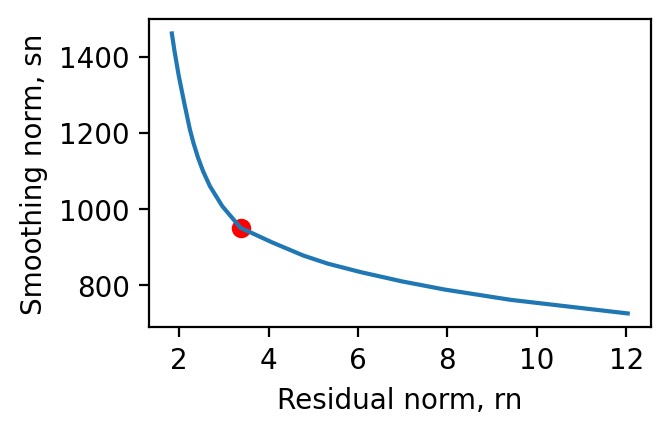

In [108]:
expression_find_gamma.find_optimal_gamma(kappa=0.001, verbose=False)

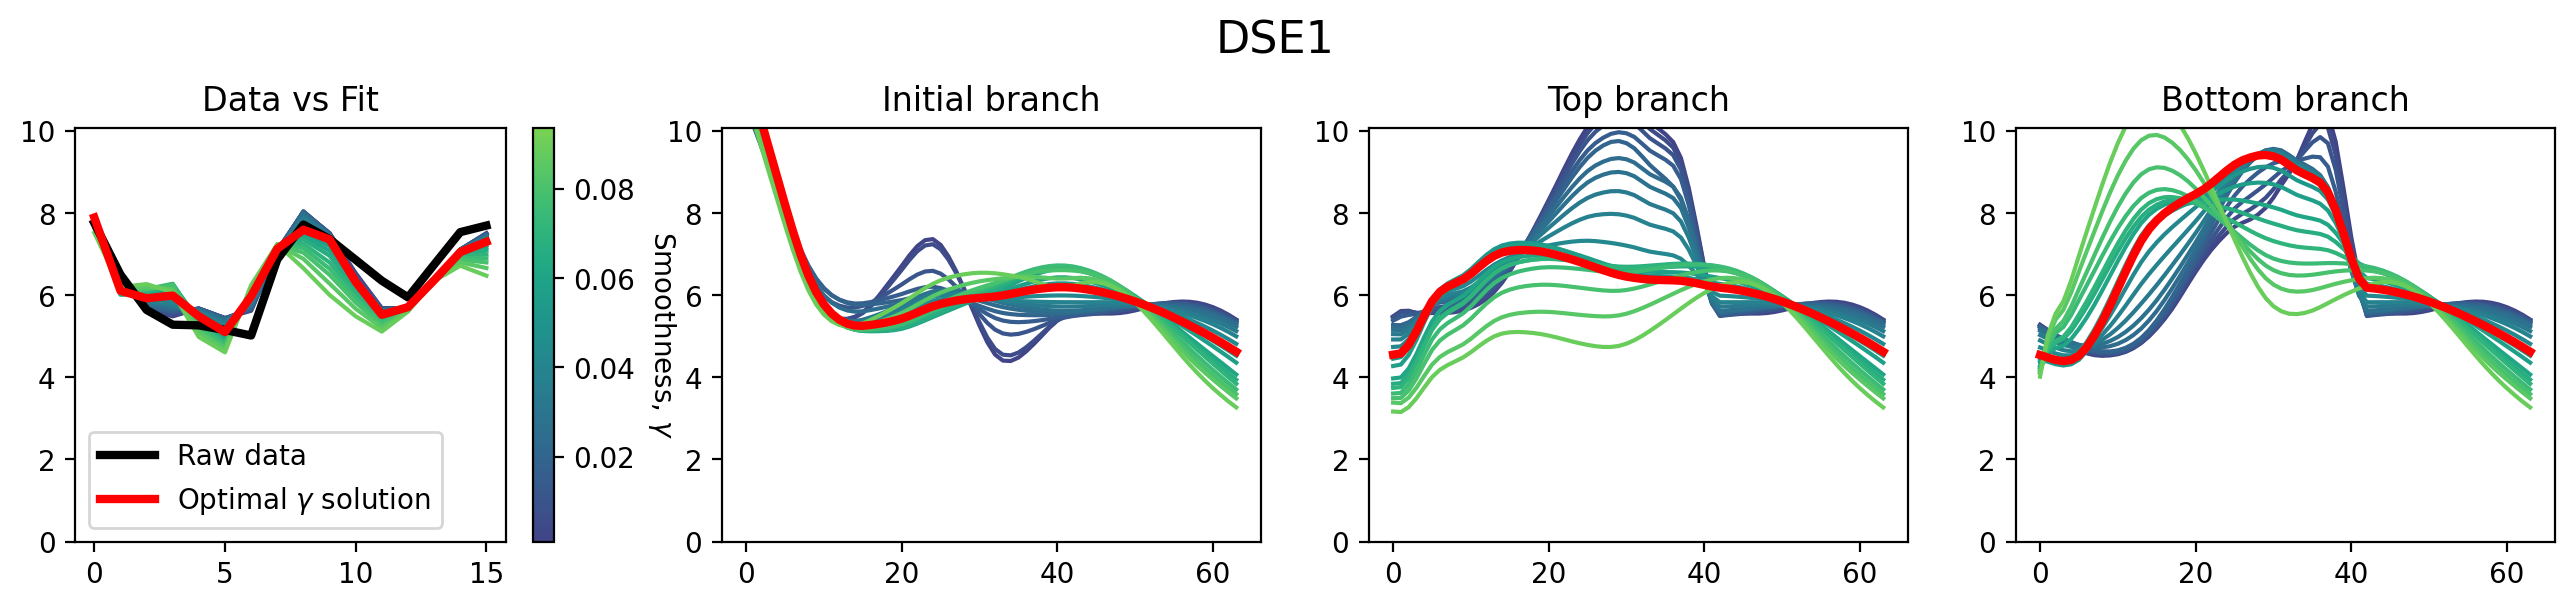

In [109]:
expression_find_gamma.plot_gamma_sweep()
plt.suptitle(gene_name, fontsize=16)
plt.subplots_adjust(top=0.8)


In [221]:
# Planning - Determine a way to identify an optimal kappa value
# to regularize the mother and daughter branches.
# Goal: Identifies daughter-specific gene expression, without introducing false positive
# gene expression for mothers. Using Guo's published results as a reference point


In [110]:
from src.find_optimal_kappa import FindKappaExpression
find_kappa = FindKappaExpression(config1)

In [111]:
find_kappa.sweep_kappas()

[1/20]Kappa= 0.0001
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:01:29.549

[2/20]Kappa= 0.0001438449888287663
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:02:56.466

[3/20]Kappa= 0.00020691380811147902
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:04:08.243

[4/20]Kappa= 0.00029763514416313193
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:05:27.007

[5/20]Kappa= 0.00042813323987193956
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:06:48.775

[6/20]Kappa= 0.0006158482110660267
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:08:19.042

[7/20]Kappa= 0.0008858667904100823
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:09:51.113

[8/20]Kappa= 0.0012742749857031334
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,RPL1B,RPL2A,RPL2B,	00:11:16.038

[9/20]Kappa= 0.0018329807108324356
	DSE1,DSE2,DSE3,DSE4,CLB2,CLN2,MCM6,CDC45,RPL1A,R

In [112]:
find_kappa.compute_l2tb()

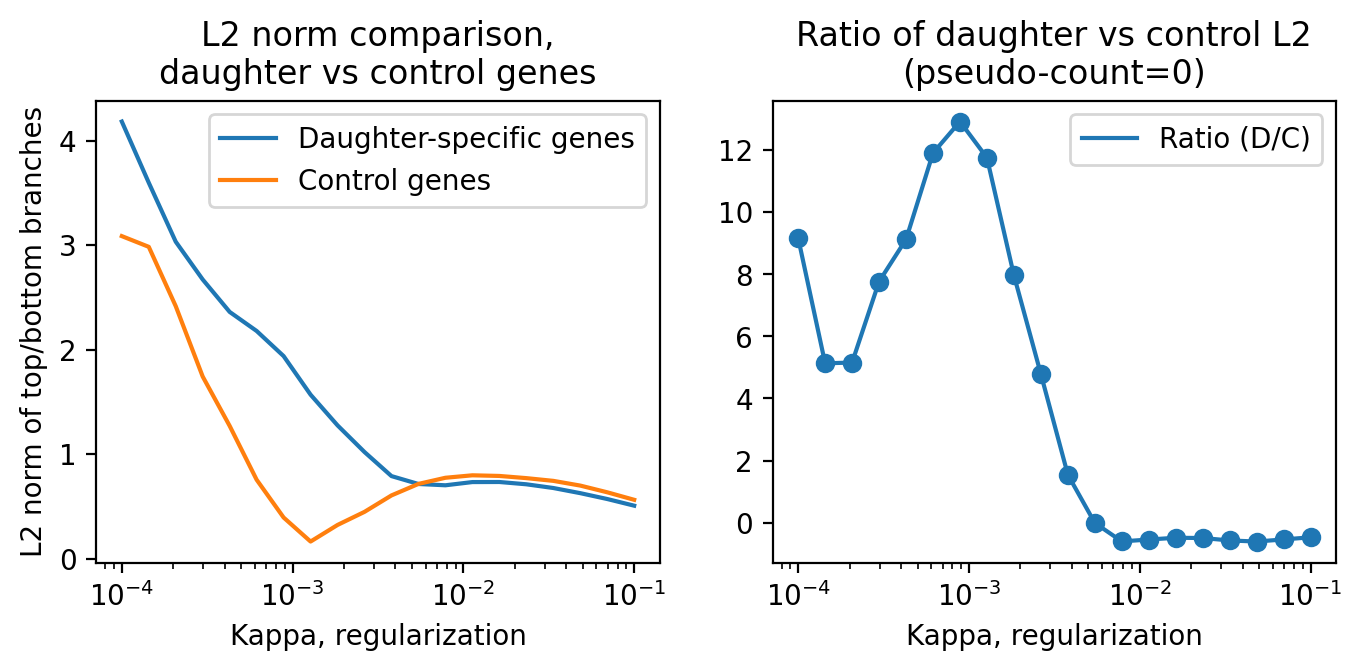

In [113]:
find_kappa.plot_l2_tb()

In [114]:
# Skip the first four values and find the argmax
offset = 4
optimal_idx = find_kappa.snr_l2.iloc[offset:].argmax()+offset
optimal = pd.DataFrame(find_kappa.snr_l2).iloc[optimal_idx]
optimal_kappa, optimal_snr = optimal.name, optimal.values[0]
optimal_idx, optimal_kappa

(6, 0.0008858667904100823)

In [115]:
# find_kappa.gene_f_solutions

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


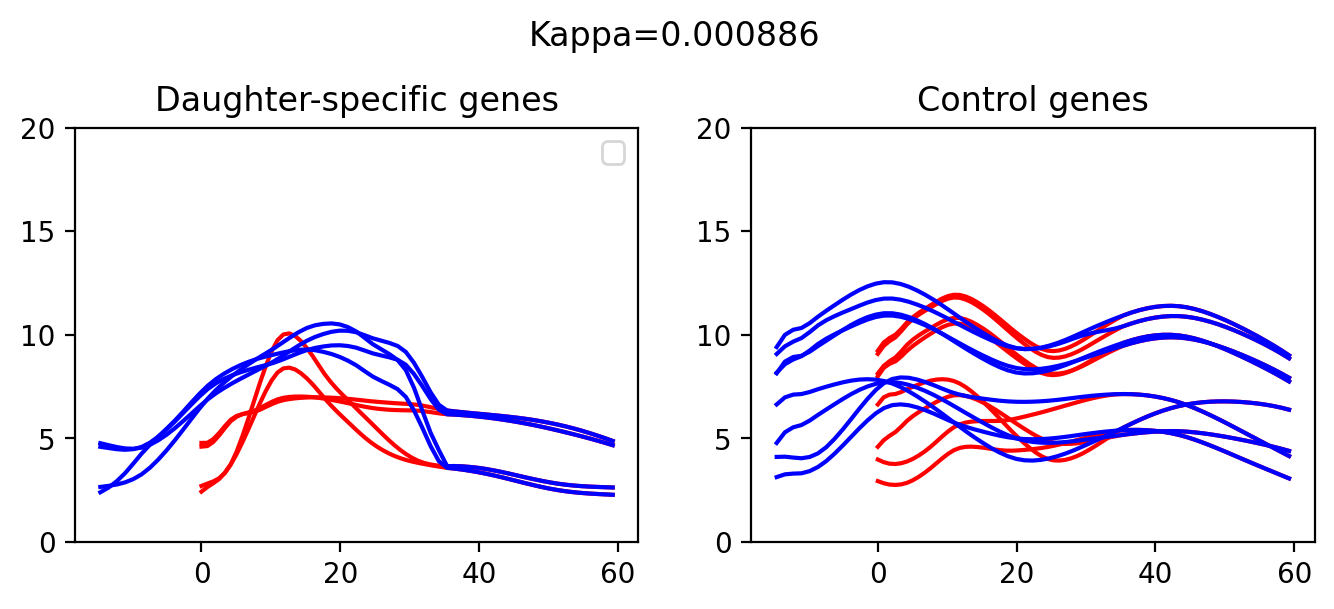

In [116]:
find_kappa.plot_example_kappa(optimal_idx)

	Base error (γ=0):	rn: 1.031852	sn: 167284.891903
	Error boundaries:
		Left:
			Relative (1.05 * e0): 1.08344
			Absolute (e0 + 0.04): 1.07185
			Chosen: 1.071852
		Right:
			Relative (4.00 * e0): 4.12741
			Absolute (e0 + 11.00): 12.0319
			Chosen: 12.031852
	Searching for left boundary gamma...
		γ: 0.0505	rn: 7.2549	sn: 802.5742
		γ: 0.02575	rn: 5.1189	sn: 863.8710
		γ: 0.013375	rn: 3.5399	sn: 940.4545
		γ: 0.0071875	rn: 2.7402	sn: 1040.1024
		γ: 0.00409375	rn: 2.4050	sn: 1134.0153
		γ: 0.00254688	rn: 2.2224	sn: 1209.9302
		γ: 0.00177344	rn: 2.0317	sn: 1321.4846
		γ: 0.00138672	rn: 1.9220	sn: 1391.8693
		γ: 0.00119336	rn: 1.8697	sn: 1430.7246
		γ: 0.00109668	rn: 1.8469	sn: 1448.6061
		γ: 0.00104834	rn: 1.8358	sn: 1457.6060
		γ: 0.00102417	rn: 1.8307	sn: 1461.7568
		γ: 0.00101208	rn: 1.8281	sn: 1463.9316
		γ: 0.00100604	rn: 1.8268	sn: 1465.0806
		γ: 0.00100302	rn: 1.8262	sn: 1465.6205
		γ: 0.00100151	rn: 1.8259	sn: 1465.8751
		γ: 0.00100076	rn: 1.8257	sn: 1466.0015
	Left boundary gam

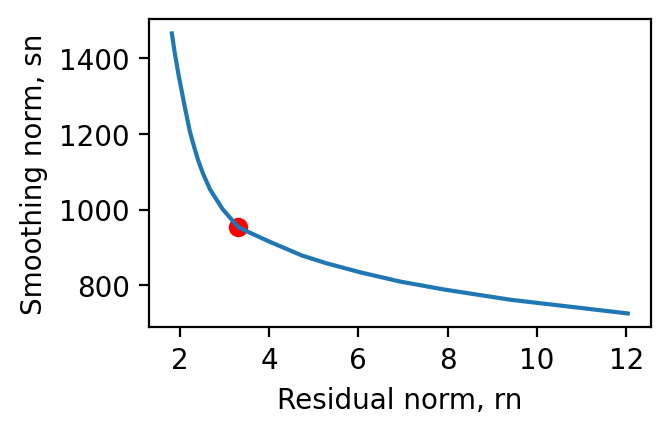

In [117]:
# from src.expression_gamma_search import GeneExpressionFindOptimalGamma

gene_name = 'DSE1'

g = load_gene_expression(gene_name)
expression_find_gamma = GeneExpressionFindOptimalGamma(config=config1, gene_expression=g,
                                                      gamma_min=0.001, gamma_max=0.1)
expression_find_gamma.find_optimal_gamma(kappa=optimal_kappa)

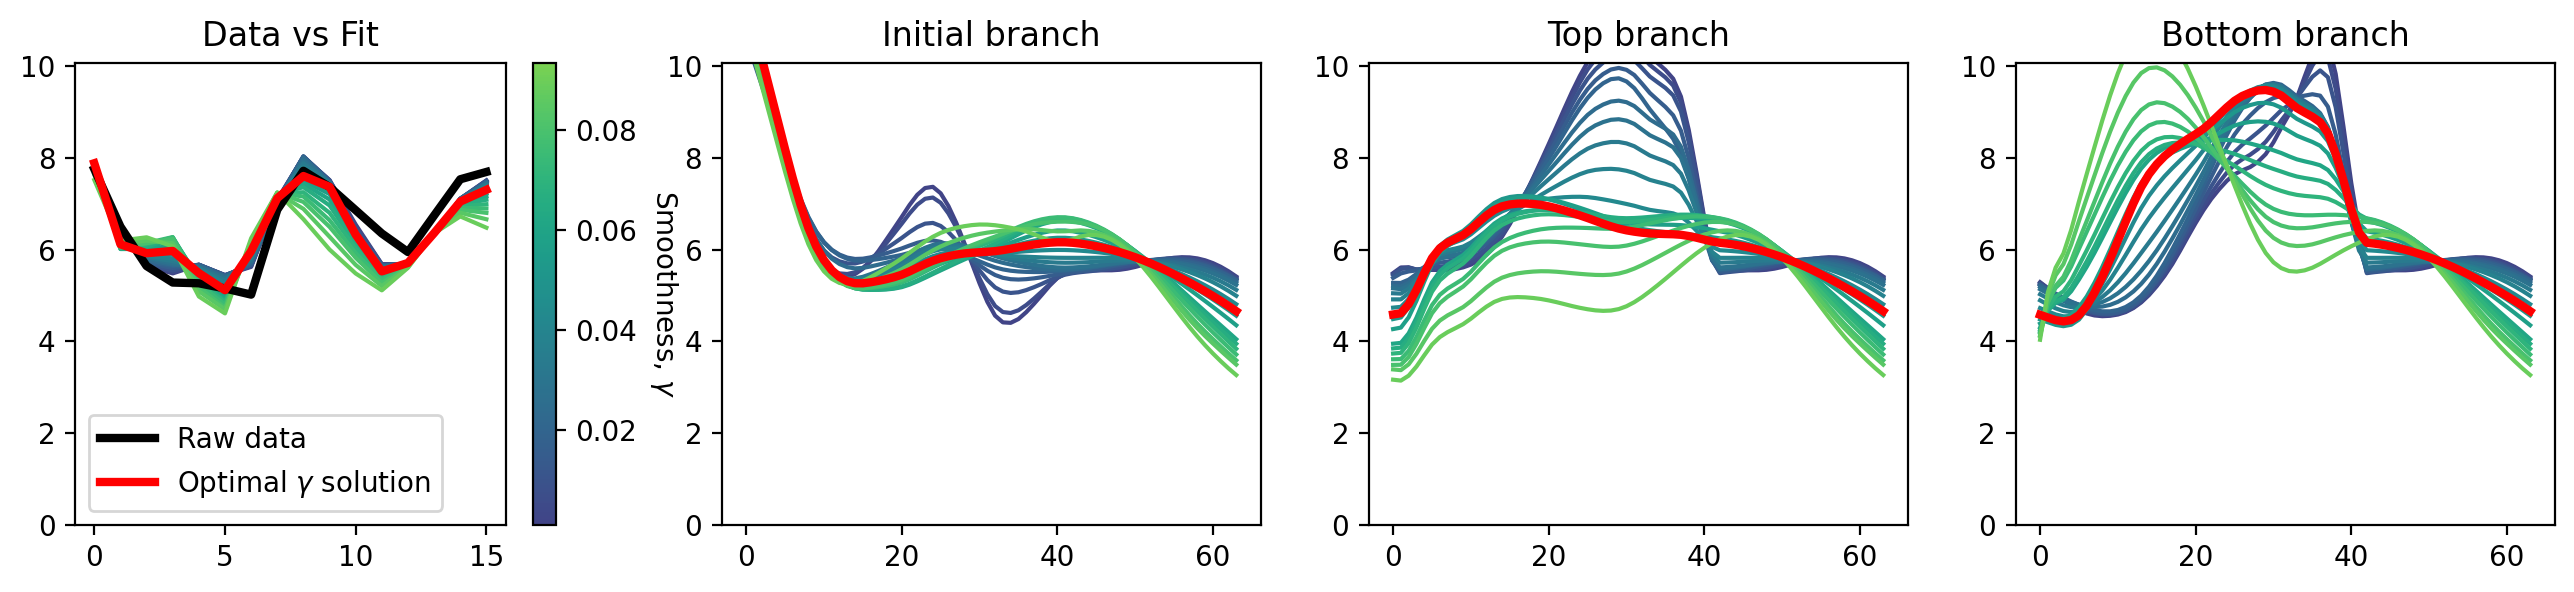

In [118]:
expression_find_gamma.plot_gamma_sweep()

In [119]:
from src.utils import mkdir_safe

outdir = 'output/gene_expression_trial_daughter_comparison'
mkdir_safe(outdir)

Creating directory: output/gene_expression_trial_daughter_comparison...Directory exists. Skipping.


In [120]:
gene_f_solutions = find_kappa.gene_f_solutions
for gene_name, kappa in gene_f_solutions.keys():
    
    if abs(kappa - optimal_kappa) < 1e-4:
        print(gene_name, kappa, optimal_kappa)
        solution_f = gene_f_solutions[(gene_name, kappa)]
        
        filepath = f"{outdir}/{gene_name}_expression_F.npy"
        np.save(filepath, solution_f)
        print(f"Saved to {filepath}")


DSE1 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/DSE1_expression_F.npy
DSE2 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/DSE2_expression_F.npy
DSE3 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/DSE3_expression_F.npy
DSE4 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/DSE4_expression_F.npy
CLB2 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/CLB2_expression_F.npy
CLN2 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/CLN2_expression_F.npy
MCM6 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_comparison/MCM6_expression_F.npy
CDC45 0.0008858667904100823 0.0008858667904100823
Saved to output/gene_expression_trial_daughter_